# How to Use Deep Learning, PyTorch Lightning, and the Planetary Computer to Predict Cloud Cover in Satellite Imagery

Welcome to the benchmark notebook for the On Cloud N: Cloud Cover Detection Challenge! If you are just getting started, check out competition [homepage](). The goal of this benchmark is to:

1. Demonstrate how to explore and work with the data
2. Provide a basic framework for building a model
3. Demonstrate how to package your work correctly for submission

You can either expand on and improve this benchmark, or start with something completely different! Let's get started.

Satellite imagery is critical for a wide variety of applications from disaster management and recovery, to agriculture, to military intelligence. Clouds present a major obstacle for all of these use cases, and usually have to be identified and removed from a dataset before satellite imagery can be used. Improving methods of identifying clouds can unlock the potential of an unlimited range of satellite imagery use cases, enabling faster, more efficient, and more accurate image-based research.

**In this challenge, your goal is to detect cloud cover in satellite imagery**.

The challenge uses publicly available satellite data from the [Sentinel-2 mission](), which captures wide-swath, high-resolution, multi-spectral imaging. For each tile, data is separated into 13 spectral bands capturing the full visible spectrum, near-infrared, and infrared light. Feature data is shared through Microsoft's [Planetary Computer]().

The ground truth labels for cloud cover are part of a new dataset created by [Radiant Earth Foundation](). After the competition ends, the labels dataset will be made publicly available to contribute to ongoing learning and advancement in the field.

In this post, we'll cover:
- Exploring the data
- Preparing the data
- Following the code execution submission format
- Building the benchmark model
- Fitting the benchmark model
- Generating a code execution submission

In [622]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [623]:
%pip install loguru matplotlib numpy opencv-python pandas pandas_path pillow pyproj pytorch_lightning rasterio scikit-learn segmentation-models-pytorch torch torchvision tqdm transformers typer xarray xarray-spatial #--index-url https://download.pytorch.org/whl/cu124

Note: you may need to restart the kernel to use updated packages.


In [624]:

import rasterio

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch

import warnings
warnings.filterwarnings("ignore")

print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.__version__)

False
None
2.11.0


## Explore the data

First, we'll download all the data to a local folder. For instructions, see the competition's data download [page](). You'll need to join the competition in order to view the data page.

Data directory contents:
```
.
├── train_features
│   ├── train_chip_id_1
│   │   ├── B02.tif
│   │   ├── B03.tif
│   │   ├── B04.tif
│   │   └── B08.tif
│   └── ... 
├── train_metadata.csv
└── train_labels
    ├── train_chip_id_1.tif
    └── ...
```

In [625]:
import os

metadata_dir = Path.cwd().parent.resolve() / Path("data/GF1_B02_B03_B04_B08_Mask")
metadata_path = metadata_dir / "metadata.csv"
df = pd.read_csv(metadata_path)

def update_path(row):
    file_suffix = ".tif"
    filename = row["filename"] + file_suffix
    path = os.path.join(metadata_dir, filename)
    return path

df["path"] = df.apply(update_path, axis=1)
df.head(10)

,filename,location,datetime,path
0,GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476,E102.0-N28.0,2014/3/2,/Users/hangzegao/PycharmProjects/cloud/data/GF...
1,GF1_WFV1_E104.1_S0.6_20151012_L2A0001096133,E104.1-S0.6,2015/10/12,/Users/hangzegao/PycharmProjects/cloud/data/GF...
2,GF1_WFV1_E104.3_N12.9_20140522_L2A0000356326,E104.3-N12.9,2014/5/22,/Users/hangzegao/PycharmProjects/cloud/data/GF...
3,GF1_WFV1_E104.8_N51.3_20150617_L2A0000979951,E104.8-N51.3,2015/6/17,/Users/hangzegao/PycharmProjects/cloud/data/GF...
4,GF1_WFV1_E114.4_N38.0_20130505_L2A0000029007,E114.4-N38.0,2013/5/5,/Users/hangzegao/PycharmProjects/cloud/data/GF...
5,GF1_WFV1_E115.1_N49.6_20140423_L2A0000314913,E115.1-N49.6,2014/4/23,/Users/hangzegao/PycharmProjects/cloud/data/GF...
6,GF1_WFV1_E116.5_N19.6_20130508_L2A0000022031,E116.5-N19.6,2013/5/8,/Users/hangzegao/PycharmProjects/cloud/data/GF...
7,GF1_WFV1_E119.1_N36.3_20131118_L2A0000117883,E119.1-N36.3,2013/11/18,/Users/hangzegao/PycharmProjects/cloud/data/GF...
8,GF1_WFV1_E120.2_N53.0_20150705_L2A0000939154,E120.2-N53.0,2015/7/5,/Users/hangzegao/PycharmProjects/cloud/data/GF...
9,GF1_WFV1_E124.1_N49.6_20130516_L2A0000022014,E124.1-N49.6,2013/5/16,/Users/hangzegao/PycharmProjects/cloud/data/GF...


The training data consists of 11,748 "chips". Each chip is imagery of a specific area captured at a specific point in time. There are four images associated with each chip in the competition data. Each image within a chip captures light from a different range of wavelengths, or "band". For example, the B02 band for each chip shows the strengh of visible blue light, which has a wavelength around 492 nanometers (nm). The bands provided are:

| Band | Description | Center wavelength |
|------|-------------|-------------------|
| B02 | Blue visible light | 497 nm |
| B03 | Green visible light | 560 nm |
| B04 | Red visible light | 665 nm |
| B08 | Near infrared light | 835 nm |

In [626]:
BANDS = ["B02", "B03", "B04", "B08"]

In [627]:
TRAIN_FEATURES = Path.cwd().parent.resolve() / "data/metadata"
TEST_FEATURES = TRAIN_FEATURES
assert TRAIN_FEATURES.exists()

### Metadata

Let's start by looking at the metadata for the train set, to understand what the images in this competition capture.

In [628]:
csv_files = list(TRAIN_FEATURES.glob("*metadata.csv"))
csv_files

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/download_metadata.csv'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/HRC_WHU_metadata.csv'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_metadata.csv'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/RICE2_metadata.csv'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813_metadata.csv')]

In [629]:
training_targets_txt = TRAIN_FEATURES / "training_targets.txt"
with open(training_targets_txt, 'r', encoding='utf-8') as f:
    training_targets = [line.strip() for line in f if line.strip()]
training_targets

['GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081']

In [630]:
selected_csv_files = [csv_file for csv_file in csv_files if csv_file.name.replace("_metadata.csv", "") in training_targets]
selected_csv_files

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/metadata/GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_metadata.csv')]

In [631]:
df_list = []

for x in selected_csv_files:
    df = pd.read_csv(x)
    df_list.append(df)

train_meta = pd.concat(df_list, ignore_index=True).drop_duplicates()
len(train_meta)

550

In [632]:
# how many different chip ids, locations, and datetimes are there?
train_meta[["chip_id", "location", "datetime"]].nunique()

chip_id     550
location      1
datetime      1
dtype: int64

We have one row per chip, and each `chip_id` is unique. There are columns for:
- `location`: General location of the chip
- `datetime`: Date and time the satellite image was captured
- `cloudpath`: All of the satellite images for this competition are hosted on Azure Blob Storage containers.

Let's take a look at the distribution of chips by location.

In [633]:
train_location_counts = (
    train_meta.groupby("location")["chip_id"].nunique().sort_values(ascending=False)
)

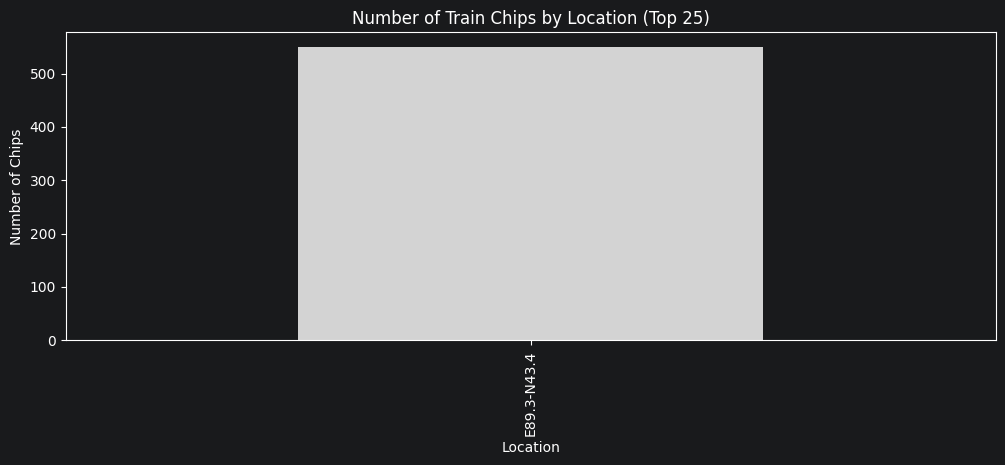

In [634]:
plt.figure(figsize=(12, 4))
train_location_counts.head(25).plot(kind="bar", color="lightgray")
plt.xticks(rotation=90)
plt.xlabel("Location")
plt.ylabel("Number of Chips")
plt.title("Number of Train Chips by Location (Top 25)")
plt.show()

The train and test images are from all over the world! Location names can be countries, cities, or broader regions. Sentinel-2 flies over the part of the Earth between 56° South and 82.8° North. The chips are mostly in Africa and South America, with some in Australia too.

We also have a timestamp for each chip. What is the time range in the data?

In [635]:
train_meta["datetime"] = pd.to_datetime(train_meta["datetime"])
train_meta["year"] = train_meta.datetime.dt.year
train_meta.groupby("year")[["chip_id"]].nunique().sort_index().rename(
    columns={"chip_id": "chip_count"}
)

,chip_count
year,
2013,550


In [636]:
train_meta["datetime"].min(), train_meta["datetime"].max()

(Timestamp('2013-07-14 00:00:00'), Timestamp('2013-07-14 00:00:00'))

In [637]:
chips_per_locationtime = (
    train_meta.groupby(["location", "datetime"])[["chip_id"]]
    .nunique()
    .sort_values(by="chip_id", ascending=False)
    .rename(columns={"chip_id": "chip_count"})
)
chips_per_locationtime.head(10)

,,chip_count
location,datetime,
E89.3-N43.4,2013-07-14,550


All of the images in the data were captured between February of 2018 and September of 2020. We can also see from the training data that many chips share the same location and time.

We know from the problem description that all of the locations in the test set are new, and there is no overlap between locations in the train set and the test set.

#### Images

Next, let's explore the actual satellite images - the star of the show for this challenge!

For convenience, let's first add the paths to all of the feature images per chip.

def add_paths(df, feature_dir, label_dir=None, bands=BANDS):
    """
    Given dataframe with a column for chip_id, returns a dataframe with a column
    added indicating the path to each band's TIF image as "{band}_path", eg "B02_path".
    A column is also added to the dataframe with paths to the label TIF, if the
    path to the labels directory is provided.
    """
    for band in bands:
        df[f"{band}_path"] = feature_dir / df["chip_id"] / f"{band}.tif"
        assert df[f"{band}_path"].path.exists().all()
    if label_dir is not None:
        df["label_path"] = label_dir / (df["chip_id"] + ".tif")
        assert df["label_path"].path.exists().all()

    return df

train_meta = add_paths(train_meta, TRAIN_FEATURES, TRAIN_LABELS)
train_meta.head()

Each image is a GeoTIFF, a raster image file that contains geographic metadata. This metadata can include coordinates, an affine transform, and a coordinate reference system (CRS) projection. The package rasterio makes it easy to interact with our geospatial raster data.

Lets look at the red visible band (B04) image for a random chip.

In [638]:
example_chip = train_meta.head()
display(example_chip)

,chip_id,location,datetime,x_start,x_end,y_start,y_end,B02_path,B03_path,B04_path,B08_path,label_path,year
0,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,E89.3-N43.4,2013-07-14,2045,2557,0,512,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/la...,2013
1,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,E89.3-N43.4,2013-07-14,3681,4193,0,512,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/la...,2013
2,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,E89.3-N43.4,2013-07-14,4090,4602,0,512,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/la...,2013
3,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,E89.3-N43.4,2013-07-14,4499,5011,0,512,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/la...,2013
4,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,E89.3-N43.4,2013-07-14,4908,5420,0,512,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/la...,2013


In [639]:
example_chip = example_chip.iloc[0]
with rasterio.open(example_chip["B04_path"]) as img:
    chip_metadata = img.meta
    img_array = img.read(1)

chip_metadata

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32645"]]'),
 'transform': Affine(15.461295979352826, 0.0, 635687.281057841,
        0.0, -15.461295979352144, 4936808.643577992)}

We can see that the features are single-band images, with a shape of 512 x 512. The pixel values for each image measure the strength of light reflected back to the satellite for the specific set of wavelengths in that band.

In [640]:
# what does the image array look like?
print("Image array shape:", img_array.shape)
img_array

Image array shape: (512, 512)


array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [643, 653, 658, ..., 613, 611, 608],
       [628, 636, 633, ..., 591, 591, 594],
       [641, 618, 593, ..., 557, 559, 562]],
      shape=(512, 512), dtype=uint16)

In [641]:
np.isnan(img_array).sum()

np.int64(0)

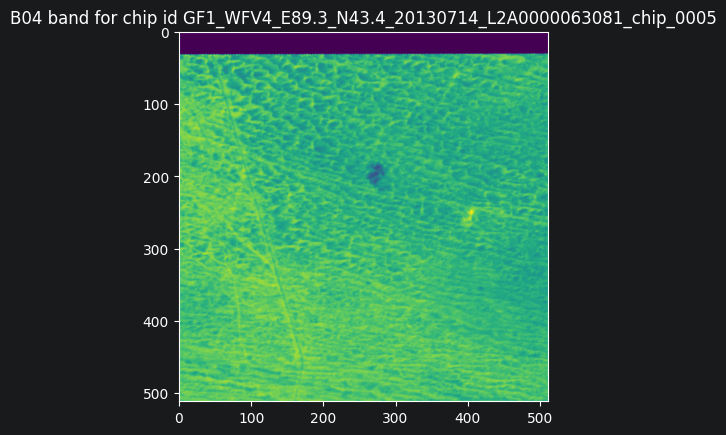

In [642]:
plt.imshow(img_array)
plt.title(f"B04 band for chip id {example_chip.chip_id}")
plt.show()

##### Coordinates

Using the metadata returned by `rasterio`, we can also get longitude and latitude coordinates.

In [643]:
# longitude/latitude of image's center
with rasterio.open(example_chip["B04_path"]) as img:
    lon, lat = img.lnglat()
    bounds = img.bounds
print(f"Longitude: {lon}, latitude: {lat}")

Longitude: 88.75765605872978, latitude: 44.53546052385766


bounds

We have the longitude and latitude of the center of the image, but the bounding box values look very different. That's because the bounding box is given in whatever coordinate reference system the image is projected in. We can convert the bounding box to longitude and latitude using `pyproj`.

In [644]:
import pyproj

def lat_long_bounds(filepath):
    """Given the path to a GeoTIFF, returns the image bounds in latitude and
    longitude coordinates.

    Returns points as a tuple of (left, bottom, right, top)
    """
    with rasterio.open(filepath) as im:
        bounds = im.bounds
        meta = im.meta
    # create a converter starting with the current projection
    current_crs = pyproj.CRS(meta["crs"])
    crs_transform = pyproj.Transformer.from_crs(current_crs, current_crs.geodetic_crs)

    # returns left, bottom, right, top
    return crs_transform.transform_bounds(*bounds)

left, bottom, right, top = lat_long_bounds(example_chip["B04_path"])
print(f"Image coordinates (lat, long):\nStart: ({left}, {bottom})\nEnd: ({right}, {top})")

Image coordinates (lat, long):
Start: (44.49906740169081, 88.70681921361286)
End: (44.57183359656274, 88.80855355141657)


##### True color image

We can make a composite image from the three visible bands (blue, green, and red) to visualize a high-quality, true color image.

In [645]:
import xarray
import xrspatial.multispectral as ms

def get_xarray(filepath):
    """Put images in xarray.DataArray format"""
    im_arr = np.array(Image.open(filepath))
    return xarray.DataArray(im_arr, dims=["y", "x"])

def true_color_img(chip):
    """Given the path to the directory of Sentinel-2 chip feature images,
    plots the true color image"""
    red = get_xarray(chip.B04_path)
    green = get_xarray(chip.B03_path)
    blue = get_xarray(chip.B02_path)

    return ms.true_color(r=red, g=green, b=blue)

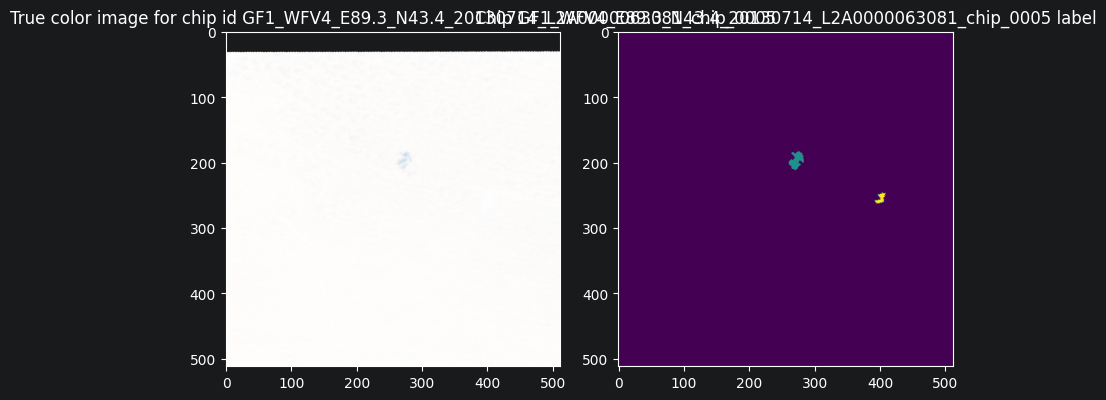

In [646]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
im = true_color_img(example_chip)
ax[0].imshow(im)
ax[0].set_title(f"True color image for chip id {example_chip.chip_id}")
label_im = Image.open(example_chip["label_path"])
ax[1].imshow(label_im)
ax[1].set_title(f"Chip {example_chip.chip_id} label")
plt.tight_layout()
plt.show()

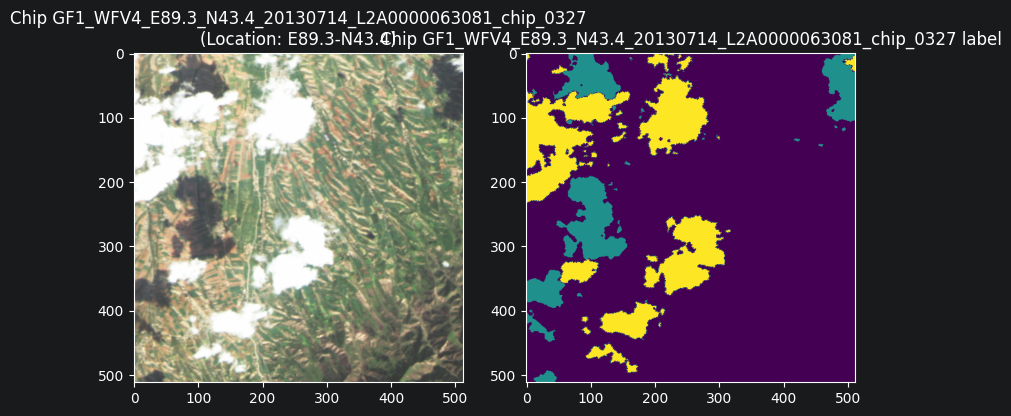

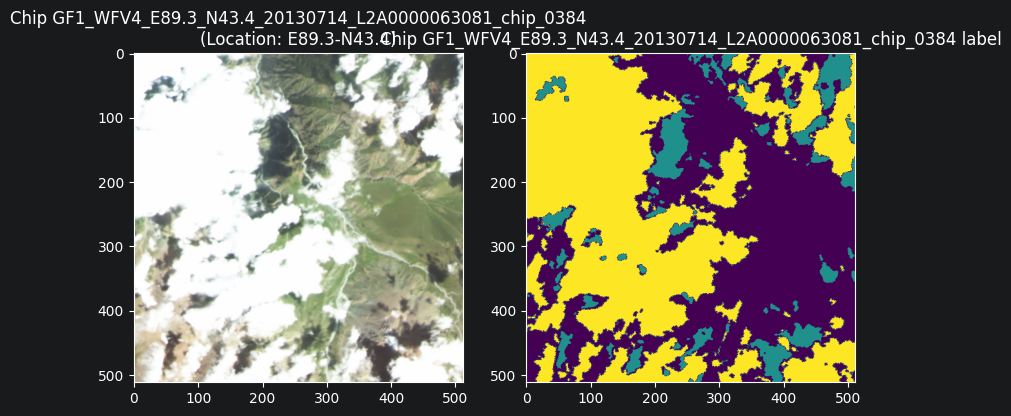

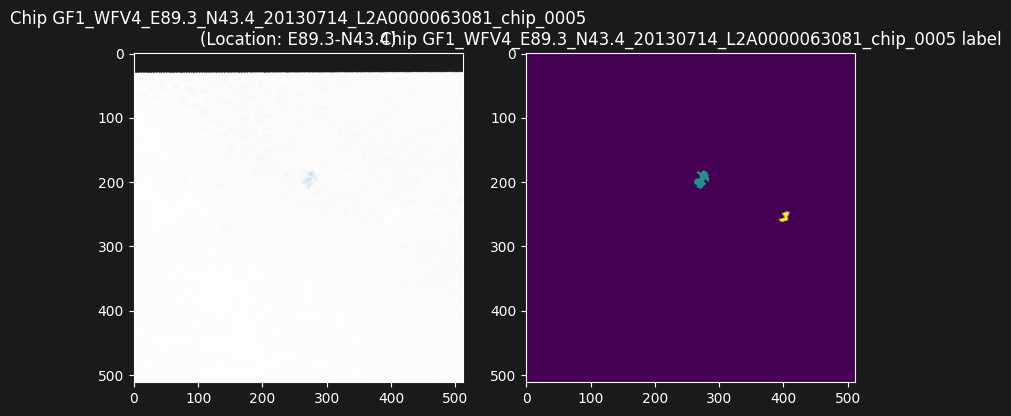

In [647]:
def display_random_chip(random_state):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    random_chip = train_meta.sample(random_state=random_state).iloc[0]
    ax[0].imshow(true_color_img(random_chip))
    ax[0].set_title(f"Chip {random_chip.chip_id}\n(Location: {random_chip.location})")
    label_im = Image.open(random_chip.label_path)
    ax[1].imshow(label_im)
    ax[1].set_title(f"Chip {random_chip.chip_id} label")

    plt.tight_layout()
    plt.show()

display_random_chip(1)
display_random_chip(9)
display_random_chip(40)

From the example chips, we can see that there is a very big variation in the amount of cloud cover per chip.

### Split the data

To train our model, we want to separate the data into a "training" set and a "validation" set. That way we'll have a portion of labelled data that was not used in model training, which can give us a more accurate sense of how our model will perform on the competition test data.

We have chosen the simplest route, and split our training chips randomly into 1/3 validation and 2/3 training.

In [648]:
import random

random.seed(9)  # set a seed for reproducibility

# put 1/3 of chips into the validation set
chip_ids = train_meta.chip_id.unique().tolist()
val_chip_ids = random.sample(chip_ids, round(len(chip_ids) * 0.33))

val_mask = train_meta.chip_id.isin(val_chip_ids)
val = train_meta[val_mask].copy().reset_index(drop=True)
train = train_meta[~val_mask].copy().reset_index(drop=True)

val.shape, train.shape

((182, 13), (368, 13))

In [649]:
# separate features from labels
feature_cols = ["chip_id"] + [f"{band}_path" for band in BANDS]

val_x = val[feature_cols].copy()
val_y = val[["chip_id", "label_path"]].copy()

train_x = train[feature_cols].copy()
train_y = train[["chip_id", "label_path"]].copy()

In [650]:
val_x.head()

,chip_id,B02_path,B03_path,B04_path,B08_path
0,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...
1,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...
2,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...
3,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...
4,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...,/Users/hangzegao/PycharmProjects/cloud/data/im...


In [651]:
val_y.head()

,chip_id,label_path
0,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/la...
1,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/la...
2,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/la...
3,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/la...
4,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081_ch...,/Users/hangzegao/PycharmProjects/cloud/data/la...


### Code Execution Format

**This is a code submission challenge! Rather than submitting your predicted labels, you'll package everything needed to do inference and submit that for containerized execution.**

Your final submission will be a zipped archive called `submission.zip`.

The final submission folder will include:
1. The weights for our trained model
2. A `main.py` script that loads the model, performs inference, generates predictions
3. Any additional scripts that `main.py` needs in order to run

`main.py` must be able to run without getting any input arguments.

In [652]:
from pathlib import Path

model_name = "unet"
benchmark_dir = Path("benchmark") / model_name

### Build the model

We'll use PyTorch Lightning. Our model will start with a publicly available convolutional neural network called U-Net that is pretrained for semantic segmentation.

**U-Net** was first designed to help process biomedical imaging. We'll use a pretrained backbone called ResNet34 as our encoder.

#### `CloudDataset`

Custom dataset class to read satellite image data, convert to tensors, and serve batches.

In [653]:
from benchmark.cloud_dataset import CloudDataset

#### `Loss class`

Custom loss for calculating intersection over union (IOU), the competition performance metric.

In [654]:
from benchmark.losses import intersection_over_union

#### `CloudModel`

Lightning Module wrapping U-Net model, training loop, validation loop, dataloaders and optimizers.

In [655]:
from benchmark.cloud_model import CloudModel

### Fit the model

In [656]:
import os
import pytorch_lightning as pl
import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

In [657]:
# Set up pytorch_lightning.Trainer object
cloud_model = CloudModel(
    bands=BANDS,
    x_train=train_x,
    y_train=train_y,
    x_val=val_x,
    y_val=val_y,
    model_name=model_name,
)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints/",
    filename="{epoch:02d}-{iou_epoch:.3f}",
    monitor="iou_epoch",
    mode="max",
    verbose=True,
    save_last=True,
)
early_stopping_callback = pl.callbacks.early_stopping.EarlyStopping(
    monitor="iou_epoch",
    patience=cloud_model.patience,
    mode="max",
    verbose=True,
)

trainer = pl.Trainer(
    accelerator="auto",
    devices="auto",
    # fast_dev_run=30,
    callbacks=[checkpoint_callback, early_stopping_callback, pl.callbacks.LearningRateMonitor(logging_interval="epoch")],
    max_epochs=8,
    # precision="16-mixed",
    precision="bf16",
    enable_checkpointing=True,
    enable_progress_bar=True,
    enable_model_summary=True,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
# Fit the model
last_ckpt = Path("checkpoints/epoch=08-iou_epoch=0.396.ckpt")
trainer.fit(
    model=cloud_model,
    # ckpt_path=last_ckpt if last_ckpt.exists() else None,
    # weights_only=False,
)

┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Unet │  6.3 M │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 6.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.3 M                                                                                                
Total estimated model params size (MB): 25                                                                         
Modules in train mode: 427                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

### Save the model

In [ ]:
# save the model
benchmark_assets_dir = benchmark_dir / "assets"
benchmark_assets_dir.mkdir(parents=True, exist_ok=True)

model_weight_path = benchmark_assets_dir / "cloud_model.pt"
torch.save(cloud_model.state_dict(), model_weight_path)